# In Transformer implementation we used Encoder but here we need decoder

- Encoder -> can see all the data
- Decoder -> can see only previous data

In [25]:
import os

import pandas as pd

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# import data

In [26]:
train_df = pd.read_csv(r"C:\Users\dhana\OneDrive\Desktop\Learning\AIML\Transformers\GPT Mini Project\TinyShakeSpeare\train.csv")
val_df = pd.read_csv(r"C:\Users\dhana\OneDrive\Desktop\Learning\AIML\Transformers\GPT Mini Project\TinyShakeSpeare\test.csv")


print(train_df.head())
print(train_df.columns)
print(train_df.shape)

                                                text
0  First Citizen:\nBefore we proceed any further,...
Index(['text'], dtype='str')
(1, 1)


In [27]:
train_text = train_df['text'][0]
val_text = val_df['text'][0]

print(train_text[:500])

print(len(train_text))

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
1003854


In [28]:
# what if a word comes which does not exist in our data
# we need to use UKN

UNK_TOKEN = "<UNK>"

all_text = train_text + val_text

words = all_text.split()
words = sorted(list(set(words)))
words = [UNK_TOKEN] + words

print(words)

vocab_size = len(words)

print(vocab_size)

['<UNK>', '&C:', '&c.', "'", "'?", "'A", "'Alas,", "'Alas,'", "'Alla", "'An", "'Ay", "'Ay,'", "'Ay.'", "'Be", "'Beseech", "'Bless", "'Bove", "'Brutus!'", "'By", "'Charge", "'Charge!", "'Citizens!'", "'Clarence", "'Come", "'Come,", "'Commend", "'Con", "'Content'", "'Coriolanus!'", "'Courage!'", "'Courage,", "'Cucullus", "'Dear", "'Death.'", "'Deny", "'Do", "'Fair", "'Faith,", "'Farewell:'", "'Fine;'", "'Fore", "'Forgive", "'G'", "'Gainst", "'Go", "'God", "'Good", "'Have", "'He", "'Heart's", "'Hell", "'Hold,", "'I", "'I'", "'I';", "'I'll", "'I,'", "'I.'", "'Is", "'It", "'Jesu", "'King", "'Lo,", "'Madam,'", "'Margaret.'", "'My", "'O", "'O,", "'Pardon'", "'Patricians!'", "'Peace,", "'Proud,'", "'Redime", "'Remember", "'Retire,'", "'Rise;'", "'Romeo", "'Saint", "'Save", "'Scape", "'Shall'!", "'She", "'Sicilia", "'Sicinius!'", "'Signior", "'Sir,", "'Sirrah,", "'Small", "'Stay,", "'Stay:", "'Tear", "'Tell", "'Thanks,", "'That", "'The", "'Then", "'They", "'This", "'Thou", "'Though", "'Thus", "

# sting to int 

# int to string

In [29]:
# String to integer
stoi = {c:i for i,c in enumerate(words)}

print(stoi)

# Integer to string
itos = {i:c for i,c in enumerate(words)}

print(itos)

# if i give a word i will gave as list of int's
def encode(text):
    words = text.split()
    return [stoi.get(w, stoi[UNK_TOKEN]) for w in words]

# if i give a int sequence i will return word
def decode(ids):
    return " ".join([itos[i] for i in ids])

{'<UNK>': 0, '&C:': 1, '&c.': 2, "'": 3, "'?": 4, "'A": 5, "'Alas,": 6, "'Alas,'": 7, "'Alla": 8, "'An": 9, "'Ay": 10, "'Ay,'": 11, "'Ay.'": 12, "'Be": 13, "'Beseech": 14, "'Bless": 15, "'Bove": 16, "'Brutus!'": 17, "'By": 18, "'Charge": 19, "'Charge!": 20, "'Citizens!'": 21, "'Clarence": 22, "'Come": 23, "'Come,": 24, "'Commend": 25, "'Con": 26, "'Content'": 27, "'Coriolanus!'": 28, "'Courage!'": 29, "'Courage,": 30, "'Cucullus": 31, "'Dear": 32, "'Death.'": 33, "'Deny": 34, "'Do": 35, "'Fair": 36, "'Faith,": 37, "'Farewell:'": 38, "'Fine;'": 39, "'Fore": 40, "'Forgive": 41, "'G'": 42, "'Gainst": 43, "'Go": 44, "'God": 45, "'Good": 46, "'Have": 47, "'He": 48, "'Heart's": 49, "'Hell": 50, "'Hold,": 51, "'I": 52, "'I'": 53, "'I';": 54, "'I'll": 55, "'I,'": 56, "'I.'": 57, "'Is": 58, "'It": 59, "'Jesu": 60, "'King": 61, "'Lo,": 62, "'Madam,'": 63, "'Margaret.'": 64, "'My": 65, "'O": 66, "'O,": 67, "'Pardon'": 68, "'Patricians!'": 69, "'Peace,": 70, "'Proud,'": 71, "'Redime": 72, "'Rememb

# Check

In [30]:
print(encode("Alas"))

test = encode("Alas")

print(decode(test))

[362]
Alas


# Converted the real data into tensors

In [31]:
train_data = torch.tensor(encode(train_text), dtype = torch.long)

print(train_data)
print(train_data.shape)


val_data = torch.tensor(encode(val_text), dtype = torch.long)

tensor([ 1527,   955,   607,  ..., 24081,  7472, 12644])
torch.Size([182499])


# check

In [32]:
print("=====Train Data=====")

print("\nOriginal ", train_text[:20])

print("\nAfter Encode ", train_data[:20])

print("\nAfter Decode ", decode(train_data[:20].tolist()))

print("\n=====Val Data=====")

print("\nOriginal ", val_text[:20])

print("\nAfter Encode ", val_data[:20])

print("\nAfter Decode ", decode(val_data[:20].tolist()))

=====Train Data=====

Original  First Citizen:
Befor

After Encode  tensor([ 1527,   955,   607, 23789, 17834,  4987, 11468, 12451, 15135, 20608,
          379,  3525, 20608,  1527,   955,  4262,  5098,  4749, 18750, 18326])

After Decode  First Citizen: Before we proceed any further, hear me speak. All: Speak, speak. First Citizen: You are all resolved rather

=====Val Data=====

Original  rance ta'en
As shall

After Encode  tensor([    0, 21613,   486, 19714, 24286,  9816, 16857,  4688, 20835,   538,
         2701, 13234, 15837, 12992,  2351, 11097, 24714, 13943,  2907, 12376])

After Decode  <UNK> ta'en As shall with either part's agreement stand? BAPTISTA: Not in my house, Lucentio; for, you know, Pitchers have


# Hyper Parameters

In [33]:
batch_size = 8
block_size = 256

n_embd = 192
n_head = 6
n_layer = 6

dropout = 0.2
learning_rate = 3e-4

max_iters = 8000
eval_interval = 500
eval_iters = 100

device = "cuda" if torch.cuda.is_available() else "cpu"

# Batch Loader

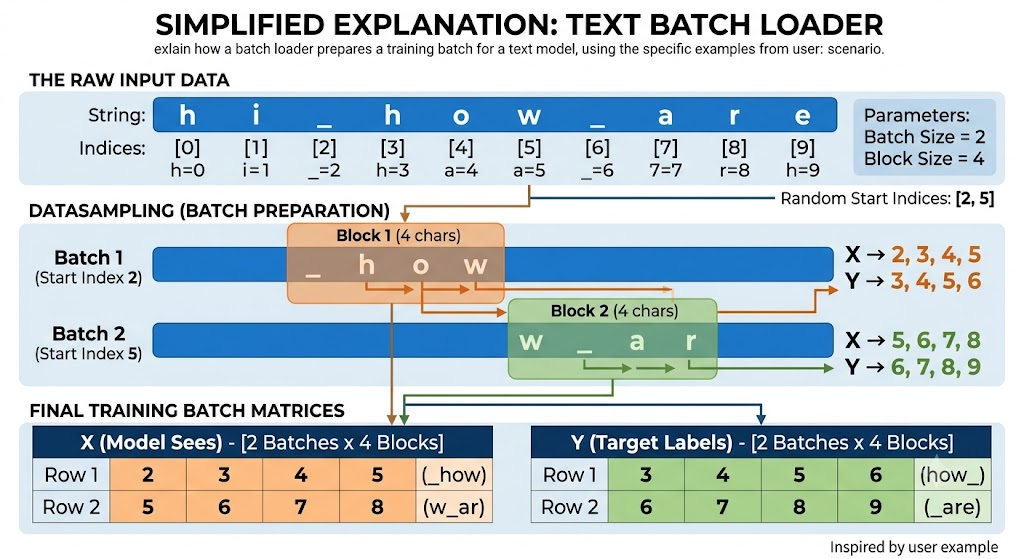

In [34]:
def get_data(split):

    data = (train_data if split == "train" else val_data)

    # random int from 0 to n
    ix = torch.randint(
        high = len(data) - block_size, # 0 to 1003854-64 (n)
        size = (batch_size,) # 32, 1
        )
    # output -> 32 random numbers

    # same as numpy stack
    x = torch.stack([
        data[i : i + block_size] # slicing
        for i in ix # iterating each element in ix
    ])

    y = torch.stack([
        data[i+1 : i + block_size + 1] # slicing with extra 1 increement
        for i in ix # iterating each element in ix
    ])

    return x, y


In [35]:
x, y = get_data("train")

print(x.shape)

print(y.shape)

torch.Size([8, 256])
torch.Size([8, 256])


# Check

In [36]:
sample_x = x[0]

sample_y = y[0]

print("=====x=====")
print(decode(sample_x.tolist()))

print("\n=====y=====")
print(decode(sample_y.tolist()))

=====x=====
love, And given his deputation all the organs Of our own power: what think you of it? ESCALUS: If any in Vienna be of worth To undergo such ample grace and honour, It is Lord Angelo. DUKE VINCENTIO: Look where he comes. ANGELO: Always obedient to your grace's will, I come to know your pleasure. DUKE VINCENTIO: Angelo, There is a kind of character in thy life, That to the observer doth thy history Fully unfold. Thyself and thy belongings Are not thine own so proper as to waste Thyself upon thy virtues, they on thee. Heaven doth with us as we with torches do, Not light them for themselves; for if our virtues Did not go forth of us, 'twere all alike As if we had them not. Spirits are not finely touch'd But to fine issues, nor Nature never lends The smallest scruple of her excellence But, like a thrifty goddess, she determines Herself the glory of a creditor, Both thanks and use. But I do bend my speech To one that can my part in him advertise; Hold therefore, Angelo:-- In our 

# Single Attention Head

In [37]:
class Head(nn.Module):
    
    def __init__(self, head_size):

        super().__init__()

        self.query = nn.Linear(
            in_features = n_embd,
            out_features = head_size,
            bias = False
        )

        self.key = nn.Linear(
            in_features = n_embd,
            out_features = head_size,
            bias = False
        )

        self.value = nn.Linear(
            in_features = n_embd,
            out_features = head_size,
            bias = False
        )

        self.register_buffer( # save it in buffer
            "tril", 
            torch.tril( # this trial convert the matrix in to a left skewed tringle and others will be 0 
                torch.ones(block_size, block_size) # create's a 64x64 ones matrix
            )
        )

        self.dropout = nn.Dropout(dropout) # Stops overfitting
    
    def forward(self, x):

        B, T, C = x.shape

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        weight = Q @ K.transpose(-2, -1) / math.sqrt(K.shape[-1])

        # Masked
        weight = weight.masked_fill(
            self.tril[:T,:T] == 0, # using the tril here so we are masking the future words using traingular matrix check below for ex
            float("-inf")
        )

        weight = F.softmax(weight, dim = -1)

        weight = self.dropout(weight)

        output = weight @ V

        return output
    

In [38]:
# weight

# The   cat   sat   down
# The   [ 2.1,  3.4, -1.2,  0.5]
# cat   [ 0.8,  1.1,  4.2, -0.9]
# sat   [-0.5,  2.2,  1.5,  3.1]
# down  [ 1.0, -0.1,  0.4,  2.8]  

# Masked

# The   cat   sat   down
# The   [ 2.1, -inf, -inf, -inf]
# cat   [ 0.8,  1.1, -inf, -inf]
# sat   [-0.5,  2.2,  1.5, -inf]
# down  [ 1.0, -0.1,  0.4,  2.8]  

# After Softmax

# The   cat   sat   down
# The   [100%,   0%,   0%,   0%]
# cat   [ 40%,  60%,   0%,   0%]
# sat   [  5%,  80%,  15%,   0%]
# down  [ 10%,   5%,  15%,  70%]

# Multi Head Attention

In [39]:
class MultiHeadAttention(nn.Module):

    def __init__(self, num_heads, head_size):

        super().__init__()

        self.heads = nn.ModuleList(
            Head(head_size)
            for _ in range(num_heads)
        )
        
        self.proj = nn.Linear(n_embd, n_embd)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        output = torch.cat(
            [h(x) for h in self.heads],
            dim = -1
            )
        
        output = self.proj(output)

        output = self.dropout(output)

        return output



# FFN

In [40]:
class FeedForward(nn.Module):

    def __init__(self, n_embd):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                n_embd,
                4*n_embd
            ),

            nn.GELU(),

            nn.Linear(
                4*n_embd,
                n_embd
            ),

            nn.Dropout(dropout)
        )

    def forward(self, x):

        return self.net(x)

# Transformer Block

In [41]:
class Block(nn.Module):

    def __init__(self, n_embd, n_head):
        super().__init__()

        head_size = n_embd // n_head

        self.sa = MultiHeadAttention(num_heads = n_head, head_size = head_size)

        self.ffwd = FeedForward(n_embd)

        self.ln1 = nn.LayerNorm(n_embd)

        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):

        x = x + self.sa(
            self.ln1(x)
        )

        x = x + self.ffwd(
            self.ln2(x)
        )

        return x

# GPT Language model

In [42]:
class GPTLanguageModel(nn.Module):
    def __init__(self):
        
        super().__init__()
        
        # token embedding: Converts token id -> vector
        self.token_embedding_table = nn.Embedding(num_embeddings = vocab_size, embedding_dim = n_embd)

        # positional embedding: tells model whether token is at pos 1, 2, 3, 4.
        self.pos_embedding_table = nn.Embedding(num_embeddings = block_size, embedding_dim = n_embd)

        # stack of transformer model
        self.blocks = nn.Sequential(
            *[Block(n_embd = n_embd, n_head = n_head) for _ in range(n_layer)]
        )

        # final layer norm
        self.ln_f = nn.LayerNorm(normalized_shape = n_embd)

        # Language model head: convert hidden state -> vocal lights
        self.lm_head = nn.Linear(in_features = n_embd, out_features = vocab_size)


    def forward(self, idx, targets = None):
        """
        idx: (B, T)
        targets: (B, T) or None
        """

        B, T = idx.shape

        # convert data to embeddings
        tok_emb = self.token_embedding_table(idx)            # (B, T, n_embd)

        # positional embeddings
        pos_emb = self.pos_embedding_table(                 # (T, n_embd)  
            torch.arange(T, device= idx.device)
        )

        # Combine token embedding and positional embeddings 
        x = tok_emb + pos_emb                               # (B, T, n_embd)

        # Transformer block
        x = self.blocks(x)                                  # (B, T, n_embd)

        # layer normalization
        x = self.ln_f(x)                                    # (B, T, n_embd)

        # vocab prediction
        logits = self.lm_head(x)                                 # (B, T, vocab_size)


        if targets is None:
            loss = None
        
        else:
            B, T, C = logits.shape

            # flattern for cross entropy
            logits = logits.view(B * T, C)                  # (B*T, C)

            targets = targets.view(B * T)                   # (B*T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss
    

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature = 1.0, top_k = None):
        """
        idx: (B, T)
        """
        for _ in range(max_new_tokens):

            # crop context if sequence becomes longer than block_size
            idx_cond = idx[:, -block_size:]

            # get predictions
            logits, _ = self(idx_cond)

            logits = logits[:, -1, :]

            # Apply Temperatue
            logits = logits / temperature

            # top-k Filtering
            if top_k is not None:
                values, _ = torch.topk(logits, top_k)
                logits[logits < values[:, [-1]]] = float("-inf")

            # convert to probabilities
            probs = F.softmax(logits, dim=-1)                # (B, vocab_size)

            # sample next token
            idx_next = torch.multinomial(probs, num_samples=1)  # (B, 1)

            # append to sequence
            idx = torch.cat((idx, idx_next), dim=1)          # (B, T+1)

        return idx



In [43]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            X, Y = get_data(split)
            X, Y = X.to(device), Y.to(device)

            logits, loss = model(X, Y)
            losses[k] = loss.item()

        out[split] = losses.mean()

    model.train()
    return out

In [44]:
def load_checkpoint(path):
    checkpoint = torch.load(path, map_location=device)

    model = GPTLanguageModel().to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=checkpoint["learning_rate"]
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    step = checkpoint["step"]

    print(f"Checkpoint loaded from {path} (step {step})")

    return model, optimizer, step

# Save and load Check point

In [45]:
def save_checkpoint(path, model, optimizer, step):
    checkpoint = {
        "step": step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "words": words,
        "stoi": stoi,
        "itos": itos,
        "vocab_size": vocab_size,
        "batch_size": batch_size,
        "block_size": block_size,
        "n_embd": n_embd,
        "n_head": n_head,
        "n_layer": n_layer,
        "dropout": dropout,
        "learning_rate": learning_rate
    }

    torch.save(checkpoint, path)
    print(f"Checkpoint saved at step {step} -> {path}")

In [46]:
checkpoint_path = "word_level_tinygpt_checkpoint.pth"

if os.path.exists(checkpoint_path):
    model, optimizer, start_iter = load_checkpoint(checkpoint_path)
else:
    model = GPTLanguageModel().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    start_iter = 0
    print("No checkpoint found. Starting fresh.")

Checkpoint loaded from word_level_tinygpt_checkpoint.pth (step 7500)


In [47]:
# max_iters = 8000
# 
extra_iters = 0

for iter in range(start_iter, max_iters+extra_iters):

    # every few steps evaluate train/val loss
    if iter % eval_interval == 0:
        losses = estimate_loss()
        print(
            f"step {iter}: "
            f"train loss {losses['train']:.4f}, "
            f"val loss {losses['val']:.4f}"
        )
        # save checkpoint every eval step
        save_checkpoint(checkpoint_path, model, optimizer, iter)

        
    # get batch
    xb, yb = get_data("train")
    xb, yb = xb.to(device), yb.to(device)

    # forward
    logits, loss = model(xb, yb)

    # backward
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 7500: train loss 2.0170, val loss 10.9965
Checkpoint saved at step 7500 -> word_level_tinygpt_checkpoint.pth


In [48]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = model.generate(context, max_new_tokens=500)[0].tolist()
generated_text = decode(generated_ids)
print(generated_text)

<UNK> loathed The offence cries 'God save your highness of us, you contented should you from imprisonment and the public be bold but that house some special seek. and see Maid's mild so that can of your highness' fail of such ado at a charter king, And thy seat of content. What! threat the sentence of my soul; Third Servant: Ye would have to wash him nor that I would be his house. QUEEN MARGARET: Warwick, the high reward, and thy ears not with thee to death; And but he were flint, King Henry's son. Look, what serpent, to him commend one good success, disdains to hell for his king That has he doth grin, to see where shall be his minority Is thither straight, would have Edward waste us And for thy him; King Henry had left hast thou speak, from shame us to right and York; Thy brother died their hate unto the time suppresseth wrongs. WARWICK: And bid me thy joints would have thy sepulchre, 3 KING HENRY VI KING HENRY VI KING HENRY VI QUEEN MARGARET: His young Henry, strengthening misproud Y

In [49]:
torch.save(model.state_dict(), "word_level_tinygpt_shakespeare_v1.pth")
print("Model weights saved!")

Model weights saved!


In [50]:
def generate_text(prompt="", max_new_tokens=300, temperature=0.8, top_k=20):
    model.eval()

    if prompt == "":
        context = torch.zeros((1, 1), dtype=torch.long, device=device)
    else:
        context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

    generated_ids = model.generate(
        context,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_k=top_k
    )[0].tolist()

    return decode(generated_ids)

In [51]:
print(generate_text("ROMEO:\n", max_new_tokens=300, temperature=0.8, top_k=20))

ROMEO: JULIET: Good morrow to your will? JULIET: At that thou hast thou hast worn thou art not by at death is not shipp'd? JULIET: I would not here: My joy of mine. JULIET: Where it is not by that; Lest that thou mayst thou hast breath as thou hast more sorrow is not the law to climb, And not an I; for the battlements of it not so, it to be in the shame till the world is too violent delights in the more than it To be more than for the more than the more than the more the more of an officer. Did I would not the more food! JULIET: Thou art a change; woe for the bones Of the more of an after-dinner's that; I am Longer to be it to the more of it To use it perceives it the more than the more I will to chide the more it perceives it to be more I not the more than the more than any language. Come, death, considering how I have it to be the most of your love to be your good path of your delight, But I have attain'd than in your delight, Or breed by the state Of celebration of your hands Of pal